# The Lotka-Volterra model
This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

You will need to make sure the required modules below are installed in your python environment

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [2]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [3]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [4]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [5]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

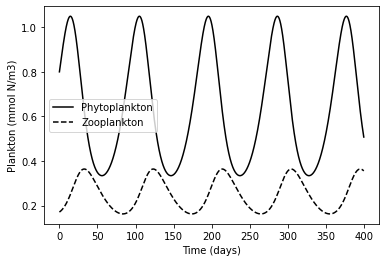

In [6]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

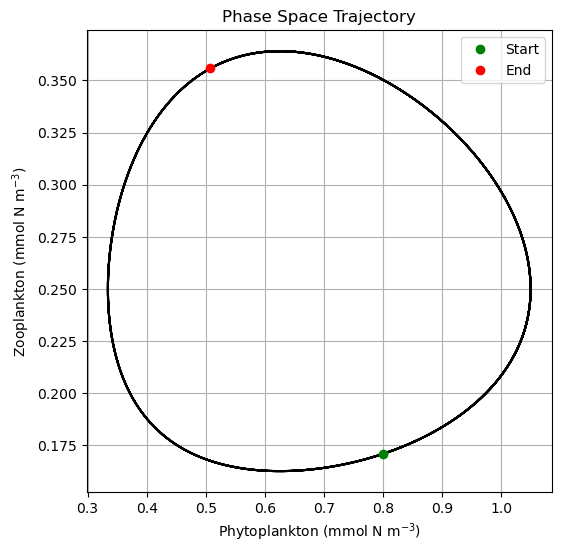

In [6]:
plt.figure(figsize=(6,6))

plt.plot(y[:,0], y[:,1], 'k-')

# Mark initial condition
plt.plot(y[0,0], y[0,1], 'go', label='Start')

# Mark final point
plt.plot(y[-1,0], y[-1,1], 'ro', label='End')

plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Phase Space Trajectory')
plt.legend()
plt.grid(True)

plt.show()

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

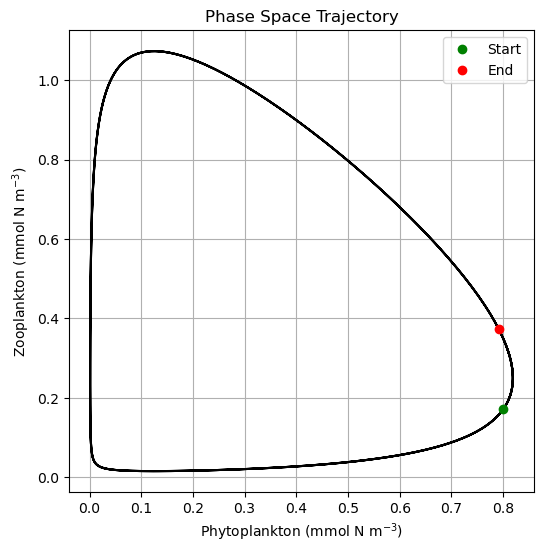

In [8]:
# Changing parameter p3=1
p_new = np.array([0.1,0.4,1,0.05])

y = odeint(LV_pz, x0, t, args=(p_new,))

# Replotting the figure
plt.figure(figsize=(6,6))

plt.plot(y[:,0], y[:,1], 'k-')

# Mark initial condition
plt.plot(y[0,0], y[0,1], 'go', label='Start')

# Mark final point
plt.plot(y[-1,0], y[-1,1], 'ro', label='End')

plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Phase Space Trajectory')
plt.legend()
plt.grid(True)

plt.show()

Changing the parameter p3=1 makes the shape of the trajectory in the phase space much more triangular rather than circular.
p3 increases the rate of assimilation of the phytoplankton by the zooplankton. This means that zooplankton growth is more sensitive to phytoplankton abundance and they are able to more grow more efficiently. This is seen in the much higher zooplankton concentrations and the more rapid assimilation of phytoplankton into zooplankton.

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

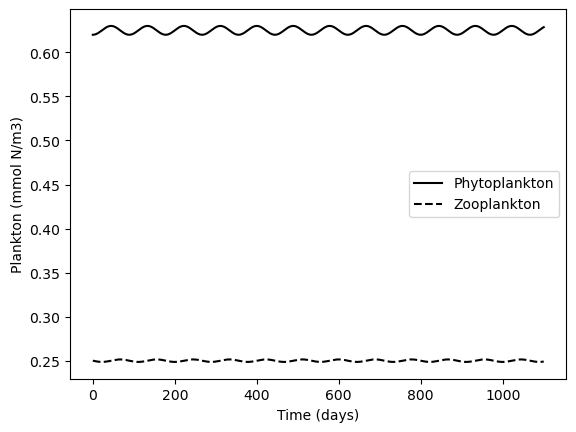

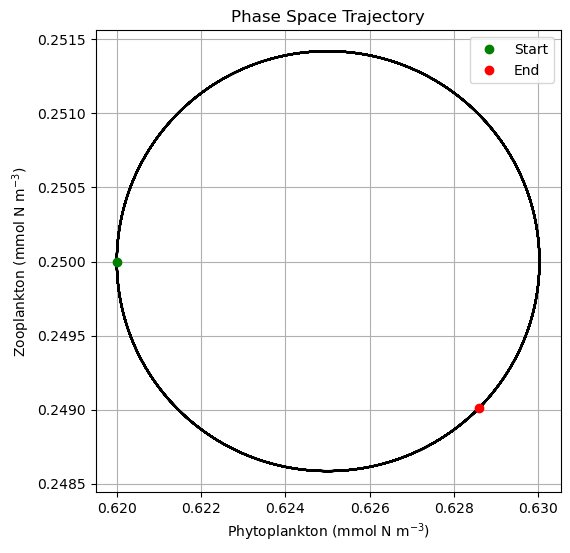

In [9]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.62
X2_0 = 0.25
x0 = np.array([X1_0,X2_0])


# time units are days
Tstart = 0.
Tend = 1100.
step = 0.1
t = np.arange(Tstart,Tend,step)

y = odeint(LV_pz, x0, t, args=(p,))

plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

plt.figure(figsize=(6,6))

plt.plot(y[:,0], y[:,1], 'k-')

# Mark initial condition
plt.plot(y[0,0], y[0,1], 'go', label='Start')

# Mark final point
plt.plot(y[-1,0], y[-1,1], 'ro', label='End')

plt.xlabel('Phytoplankton (mmol N m$^{-3}$)')
plt.ylabel('Zooplankton (mmol N m$^{-3}$)')
plt.title('Phase Space Trajectory')
plt.legend()
plt.grid(True)

plt.show()

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}

My results are not the same as the textbook. I asked AI to help explain the section on Chapter 9.

My simulation shows stable oscillations and a near perfect circular trajectory in the phase space. Fig 9.4 in the textbook shows the oscillations getting larger over time and the trajectory in the phase space spiraling. This implies the equilibrium is unstable.

According to the mathematics in the errata document, my simulation starts almost exactly at equilibrium. The Jacobian analysis also tells us that the solution to the equation should be a closed loop orbit. Fig 9.4 had a truncation and a roundoff error in the solution which generated the increasing oscillations and spiral plot.